In [5]:
import pandas as pd
import numpy as np

pd.options.display.float_format = '{:.2f}'.format

df = pd.read_csv("used_cars.csv", encoding = 'cp949')

print("컬럼별 결측치 개수")
print(df.isnull().sum(), '\n')
print("중복 행 개수")
print(df.duplicated().sum(), '\n')
print("통계 요약")
print(df.describe(), '\n')

# 결측치 삭제와 중복 제거
df = df.dropna()
df = df.drop_duplicates()

print("결측치 제거 후")
print(df.isnull().sum(), '\n')
print("중복 제거 후")
print(df.duplicated().sum(), '\n')

컬럼별 결측치 개수
브랜드        0
차량명        0
연식        15
주행거리      23
연료         0
가격(만원)     0
등록일자       0
dtype: int64 

중복 행 개수
15 

통계 요약
           연식       주행거리    가격(만원)
count  700.00     692.00    715.00
mean  2017.92  158576.30    927.31
std      3.76  534855.62   7255.47
min   2012.00    5177.00   -500.00
25%   2015.00   70884.50    100.00
50%   2018.00  130444.00    178.00
75%   2021.00  193189.50    648.00
max   2024.00 9999999.00 120000.00 

결측치 제거 후
브랜드       0
차량명       0
연식        0
주행거리      0
연료        0
가격(만원)    0
등록일자      0
dtype: int64 

중복 제거 후
0 



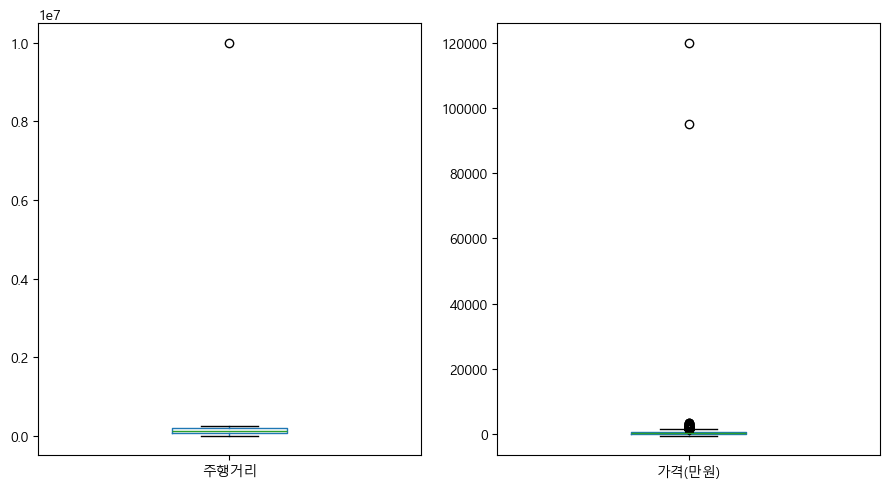

In [6]:
import matplotlib.pyplot as plt

plt.rcParams['font.family'] = 'Malgun Gothic'
plt.rcParams['axes.unicode_minus'] = False

fig, axes = plt.subplots(ncols=2, nrows=1, figsize=(9, 5))

df.boxplot(column="주행거리", ax=axes[0], grid = False, widths=0.3)
df.boxplot(column="가격(만원)", ax=axes[1], grid = False, widths=0.3)

plt.tight_layout()
plt.subplots_adjust(wspace=0.2)

plt.show()

In [8]:
# 등록일자 컬럼 이상치 처리
df['등록일자'] = df['등록일자'].astype(str)
df['등록일자'] = df['등록일자'].str.replace('.', '-', regex=False).str.replace('/', '-', regex=False)
df['등록일자'] = pd.to_datetime(df['등록일자'], errors='coerce', format='mixed')

# 주행거리와 가격 컬럼 이상치 처리(IQR)
df = df.dropna(subset=['등록일자'])
Q1_1 = df['주행거리'].quantile(0.25)
Q3_1 = df['주행거리'].quantile(0.75)
IQR_1 = Q3_1 - Q1_1
high_1 = Q3_1 + 1.5 * IQR_1

Q1_2 = df['가격(만원)'].quantile(0.25)
Q3_2 = df['가격(만원)'].quantile(0.75)
IQR_2 = Q3_2 - Q1_2
high_2 = Q3_2 + 1.5 * IQR_2

df_filtered = df[(df['주행거리'] >= 0) & (df['주행거리'] <= high_1) & (df['가격(만원)'] >= 0) & (df['가격(만원)'] <= high_2)]

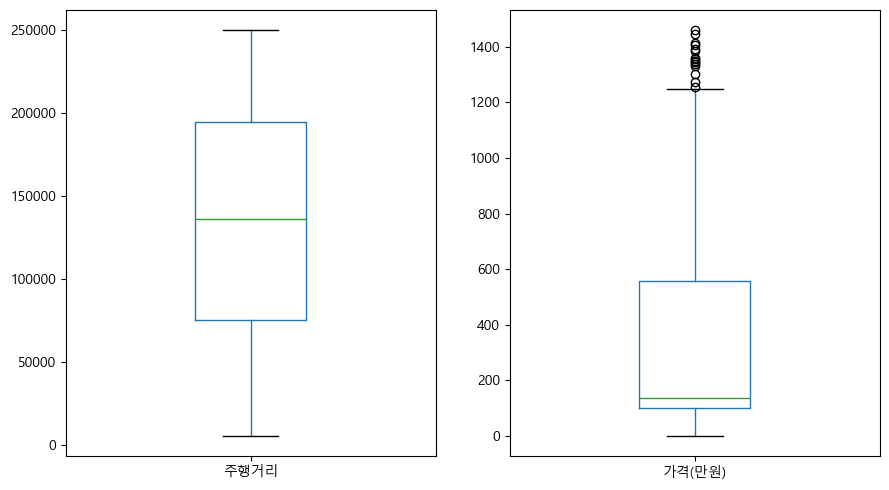

In [9]:
import matplotlib.pyplot as plt

plt.rcParams['font.family'] = 'Malgun Gothic'
plt.rcParams['axes.unicode_minus'] = False

fig, axes = plt.subplots(ncols=2, nrows=1, figsize=(9, 5))

df_filtered.boxplot(column="주행거리", ax=axes[0], grid = False, widths=0.3)
df_filtered.boxplot(column="가격(만원)", ax=axes[1], grid = False, widths=0.3)

plt.tight_layout()
plt.subplots_adjust(wspace=0.2)

plt.show()

In [ ]:
# 전처리된 데이터를 csv파일로 저장
df_filtered.to_csv("used_cars_after_preprocessing.csv", encoding = "utf-8-sig")

print(df_filtered.describe(), '\n')